In [3]:
import os
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
def show_evaluation_result(filename: str):
    with open(os.path.join("..", "assets", "evaluation_result", filename), 'r') as f:
        data = json.load(f)

    df = pd.DataFrame(data['detail'])

    df['is_correct_int'] = df['is_correct'].astype(int)

    sns.set_theme(style="whitegrid")
    plt.rcParams['figure.figsize'] = [12, 5]

    plt.figure()
    level_acc = df.groupby('level')['is_correct_int'].mean().sort_index()
    sns.barplot(x=level_acc.index, y=level_acc.values, hue =level_acc.values, legend=False, palette="viridis")
    plt.title('Accuracy by Level', fontsize=15)
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)
    for i, v in enumerate(level_acc.values):
        plt.text(i, v + 0.02, f'{v:.2f}', ha='center')
    plt.show()

    plt.figure()
    type_acc = df.groupby('type')['is_correct_int'].mean().sort_values(ascending=False)
    sns.barplot(x=type_acc.index, y=type_acc.values, hue =type_acc.values, legend=False, palette="magma")
    plt.title('Accuracy by Question Type', fontsize=15)
    plt.xticks(rotation=45) 
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)
    for i, v in enumerate(type_acc.values):
        plt.text(i, v + 0.02, f'{v:.2f}', ha='center')
    plt.show()

    summary = df.groupby(['type', 'level'])['is_correct_int'].agg(['mean', 'count']).rename(columns={'mean': 'accuracy', 'count': 'total_count'})
    print("### Level & Type Summary Table ###")
    print(summary)

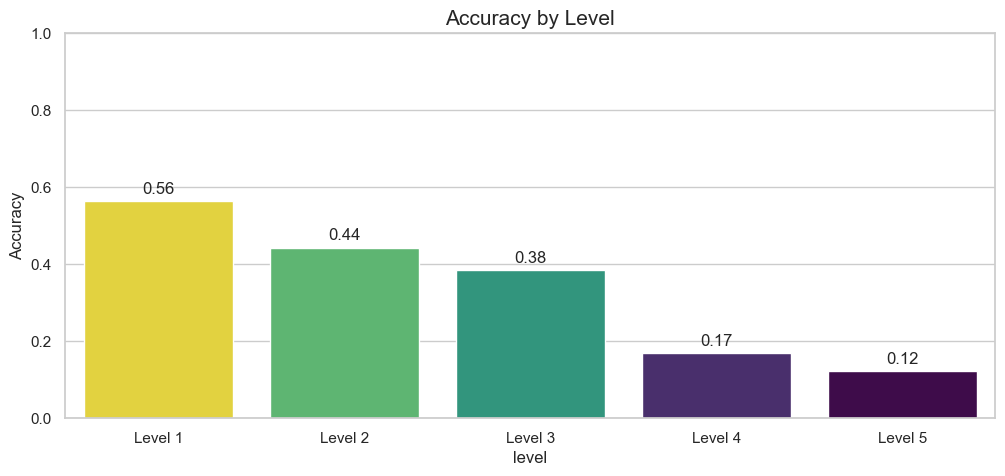

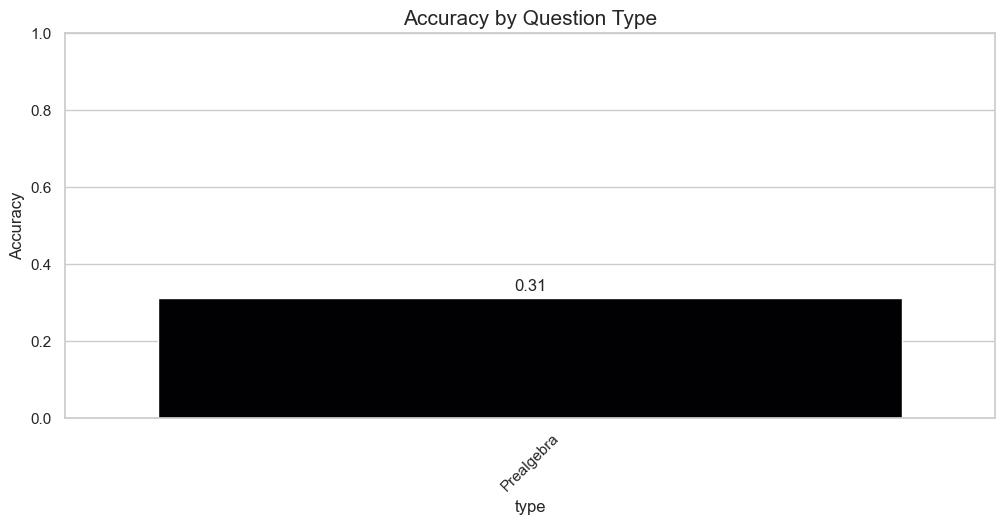

### Level & Type Summary Table ###
                    accuracy  total_count
type       level                         
Prealgebra Level 1  0.563636           55
           Level 2  0.442308          104
           Level 3  0.384000          125
           Level 4  0.168317          101
           Level 5  0.121739          115


In [10]:
show_evaluation_result("baseline_500.json")